#Tarefa: Transferência de aprendizagem

Olá,

Durante as aulas, nós usamos o modelo VGG16 para classificar ambientes internos das 5 categorias com maior número de imagens no dataset escolhido. Nesse exercício, tente adaptar a rede para classificar as 10 categorias seguintes (por número de imagens) contidas no dataset. Como o modelo desempenha tendo mais categorias e menos imagens para treinar?


== Transfer Learning ==
---

## 1. Baixando e descompactando as imagens

Link para o dataset: [http://web.mit.edu/torralba/www/indoor.html]()

In [1]:
# 1. '!' : No Jupyter/Colab, o ponto de exclamação diz ao Python:
# "Execute este comando no sistema operacional (terminal), não como código Python".

# 2. 'wget' : É uma ferramenta de linha de comando para baixar arquivos via protocolos HTTP, HTTPS e FTP.

# 3. 'http://groups.csail.mit.edu/...' : É a URL (o endereço) do arquivo.

# 4. 'indoorCVPR_09.tar' : Este é um dataset famoso (MIT Indoor Scene Recognition)
# que contém milhares de imagens de cenas internas (quartos, cozinhas, etc.) para treinar IA.

In [2]:
!wget http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar

--2026-05-01 20:09:25--  http://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Resolving groups.csail.mit.edu (groups.csail.mit.edu)... 128.52.131.233
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar [following]
--2026-05-01 20:09:26--  https://groups.csail.mit.edu/vision/LabelMe/NewImages/indoorCVPR_09.tar
Connecting to groups.csail.mit.edu (groups.csail.mit.edu)|128.52.131.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2592010240 (2.4G) [application/x-tar]
Saving to: ‘indoorCVPR_09.tar’

indoorCVPR_09.tar   100%[===================>]   2.41G  9.25MB/s    in 4m 39s  

2026-05-01 20:14:06 (8.86 MB/s) - ‘indoorCVPR_09.tar’ saved [2592010240/2592010240]



In [3]:
!tar -xvf indoorCVPR_09.tar

A saída de streaming foi truncada nas últimas 5000 linhas.
Images/mall/cover_home3.jpg
Images/mall/CP67791.jpg
Images/mall/crocker_galleria_735089.jpg
Images/mall/mall1.jpg
Images/mall/d8.jpg
Images/mall/deira_city_centre_dubai_08.jpg
Images/mall/dungarv_new_mall.jpg
Images/mall/latham_circle_mall_16.jpg
Images/mall/eastridg1.jpg
Images/mall/IMG_6449.jpg
Images/mall/main_boutique_b.jpg
Images/mall/easyfranchise_centre_commercial_1.jpg
Images/mall/ins42.jpg
Images/mall/mall14.jpg
Images/mall/eaton_centre_2001_03.jpg
Images/mall/ins43.jpg
Images/mall/mall17.jpg
Images/mall/full_shopping_Central_1.jpg
Images/mall/galleria.jpg
Images/mall/galleria1.jpg
Images/mall/galleria2.jpg
Images/mall/Galleria_003.jpg
Images/mall/laurel_mall_06.jpg
Images/mall/Galleria_1.jpg
Images/mall/galleria_san_federico_nr_109_2_n1.jpg
Images/mall/ins23.jpg
Images/mall/ins44.jpg
Images/mall/mall18.jpg
Images/mall/galleria_vittorio_emanuele_ii_milan_mlgalar.jpg
Images/mall/ins45.jpg
Images/mall/mall19.jpg
Images/m

## 2. Preparando as pastas dos datasets

In [4]:
import os
# 1. CONTAGEM DE ARQUIVOS POR PASTA:
# O os.walk('Images') percorre todas as subpastas dentro do diretório 'Images'.
# Para cada pasta, ele conta quantos arquivos existem (len(files)).
# O 'if len(files) > 0' garante que ele ignore pastas vazias ou a pasta raiz.
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]

# 2. LISTAGEM DOS NOMES DAS PASTAS (CLASSES):
# Ele faz uma nova varredura para capturar apenas os nomes das subpastas (dirs).
# O '[0]' no final pega apenas a primeira lista encontrada, que contém os nomes de todas as classes.
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]

In [5]:
num_files_per_folder

[106,
 112,
 662,
 706,
 197,
 168,
 155,
 213,
 157,
 239,
 274,
 269,
 604,
 101,
 103,
 457,
 213,
 734,
 176,
 231,
 175,
 101,
 347,
 384,
 103,
 127,
 180,
 405,
 125,
 113,
 151,
 539,
 135,
 109,
 140,
 103,
 249,
 608,
 107,
 380,
 114,
 101,
 102,
 515,
 108,
 176,
 513,
 135,
 107,
 346,
 116,
 127,
 233,
 110,
 144,
 103,
 116,
 120,
 276,
 174,
 153,
 166,
 111,
 506,
 258,
 101,
 131]

In [6]:
folders

['clothingstore',
 'children_room',
 'bedroom',
 'livingroom',
 'bathroom',
 'museum',
 'stairscase',
 'bowling',
 'jewelleryshop',
 'hairsalon',
 'dining_room',
 'winecellar',
 'bar',
 'hospitalroom',
 'florist',
 'inside_subway',
 'grocerystore',
 'kitchen',
 'auditorium',
 'gym',
 'movietheater',
 'elevator',
 'toystore',
 'pantry',
 'prisoncell',
 'kindergarden',
 'church_inside',
 'bakery',
 'laboratorywet',
 'classroom',
 'waitingroom',
 'subway',
 'operating_room',
 'office',
 'artstudio',
 'garage',
 'locker_room',
 'airport_inside',
 'library',
 'bookstore',
 'computerroom',
 'greenhouse',
 'inside_bus',
 'casino',
 'studiomusic',
 'mall',
 'restaurant',
 'closet',
 'restaurant_kitchen',
 'corridor',
 'fastfood_restaurant',
 'gameroom',
 'meeting_room',
 'videostore',
 'nursery',
 'concert_hall',
 'shoeshop',
 'cloister',
 'laundromat',
 'poolinside',
 'trainstation',
 'tv_studio',
 'buffet',
 'warehouse',
 'deli',
 'lobby',
 'dentaloffice']

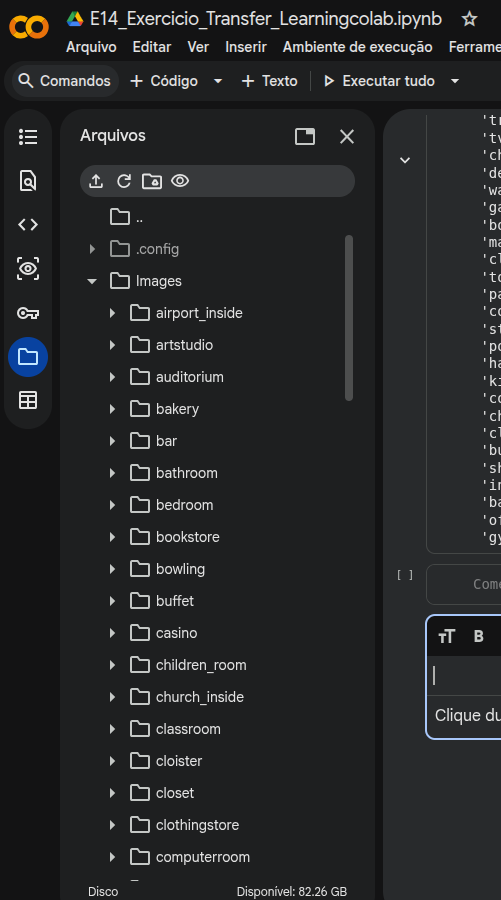

Vamos inspecionar quantas imagens cada categoria contém, em ordem decrescente.

In [7]:
print(sorted(num_files_per_folder, reverse = True))

[734, 706, 662, 608, 604, 539, 515, 513, 506, 457, 405, 384, 380, 347, 346, 276, 274, 269, 258, 249, 239, 233, 231, 213, 213, 197, 180, 176, 176, 175, 174, 168, 166, 157, 155, 153, 151, 144, 140, 135, 135, 131, 127, 127, 125, 120, 116, 116, 114, 113, 112, 111, 110, 109, 108, 107, 107, 106, 103, 103, 103, 103, 102, 101, 101, 101, 101]


Como na aula nós usamos as 5 categorias mais numerosas, agora vamos usar as 10

---

seguintes. Pra isso, podemos selecionar as categorias que contém menos de 600 imagens porém mais de 300.

In [8]:
import numpy as np

# 1. CRIAÇÃO DA MÁSCARA (FILTRO):
# Ele percorre a lista de contagem de arquivos e marca como 'True' apenas as pastas que:
# - Têm menos de 600 imagens (para não pesar demais o treino)
# - E têm mais de 300 imagens (para garantir que o modelo tenha dados suficientes para aprender)
# O 'a & b' faz a operação lógica "E" (AND) entre essas duas condições.
mask = [a & b for a, b in zip(np.array(num_files_per_folder) < 600, np.array(num_files_per_folder) > 300)]

# 2. CONFIRMAÇÃO:
# O sum(mask) conta quantos 'True' existem, ou seja, quantas categorias passaram no seu teste.
print(sum(mask))

# 3. FILTRAGEM FINAL:
# Aplica a máscara na lista original de nomes ('folders') e transforma em uma lista.
# O resultado são apenas os nomes das pastas que decidimos manter.
folders_to_keep = list(np.array(folders)[mask])

# Exibe a lista final de pastas que serão usadas no projeto
folders_to_keep

10


[np.str_('inside_subway'),
 np.str_('toystore'),
 np.str_('pantry'),
 np.str_('bakery'),
 np.str_('subway'),
 np.str_('bookstore'),
 np.str_('casino'),
 np.str_('restaurant'),
 np.str_('corridor'),
 np.str_('warehouse')]

In [9]:
import shutil # Biblioteca para operações de arquivos de alto nível (como deletar pastas cheias)

# Esta linha percorre a lista original 'folders' e, para cada pasta que NÃO
# está na sua lista de selecionadas ('folders_to_keep'), ela executa a remoção.
[shutil.rmtree('Images/' + folder) for folder in folders if folder not in folders_to_keep];

# O ';' no final serve apenas para evitar que o Jupyter/Colab imprima uma lista de
# valores 'None' na tela, deixando a saída do código limpa.

In [10]:
# 1. CONTAGEM ATUALIZADA:
# Percorre a pasta 'Images' e conta quantos arquivos (fotos) existem em cada subpasta.
# Como foi deletado das pastas indesejadas, essa lista agora só terá valores entre 300 e 600.
num_files_per_folder = [len(files) for root, dirs, files in os.walk('Images') if len(files) > 0]

# 2. NOMES DAS CATEGORIAS:
# Captura os nomes das pastas que restaram (ex: 'kitchen', 'bedroom', etc.).
# O [0] pega a lista principal de diretórios encontrada no primeiro nível da busca.
folders = [dirs for root, dirs, files in os.walk('Images') if len(dirs) > 0][0]

# 3. LISTA DE ARQUIVOS (FILENAMES):
# Cria uma lista de listas. Para cada categoria em 'folders', ele gera uma lista
# contendo o nome de todos os arquivos (.jpg) dentro dela.
# Útil se precisarmos abrir uma imagem específica pelo nome depois.
filenames = [os.listdir('Images/' + folder) for folder in folders]

# 4. EXIBIÇÃO:
# Mostra no console a relação: [quantidade de fotos] e [nomes das pastas].
num_files_per_folder, folders # Número de imagens por categoria, e nome das categorias

([457, 347, 384, 405, 539, 380, 515, 513, 346, 506],
 ['inside_subway',
  'toystore',
  'pantry',
  'bakery',
  'subway',
  'bookstore',
  'casino',
  'restaurant',
  'corridor',
  'warehouse'])

In [11]:
# 1. FIXANDO A ALEATORIEDADE:
# O computador não é verdadeiramente aleatório. O 'seed' (semente) garante que,
# se você rodar esse código 10 vezes, a "escolha aleatória" será sempre a mesma.
# Isso é fundamental para que você possa comparar resultados depois.
np.random.seed(23)

# 2. SELEÇÃO DO CONJUNTO DE TESTE:
# Esta 'list comprehension' percorre cada pasta e faz o seguinte:
# - np.random.choice: Escolhe arquivos ao acaso da lista 'filenames'.
# - round(num_files * 0.2): Define que o tamanho da escolha será 20% do total de fotos.
# - replace = False: Garante que ele não escolha a mesma foto duas vezes.
# - sorted(...): Organiza os nomes escolhidos em ordem alfabética.
files_to_test = [sorted(np.random.choice(files, round(num_files * 0.2), replace = False))
for files, num_files in zip(filenames, num_files_per_folder)]

In [12]:
# 1. CRIA A PASTA RAIZ DE TESTE:
# Cria o diretório principal chamado 'test' dentro da pasta 'Images'.
os.mkdir('Images/test/')

# 2. CRIA AS SUBPASTAS DAS CATEGORIAS:
# Para cada nome de categoria em 'folders', ele cria uma pasta correspondente dentro de 'test'.
# Exemplo: 'Images/test/kitchen', 'Images/test/bedroom', etc.
[os.mkdir('Images/test/' + folder) for folder in folders];

# 3. MOVE OS ARQUIVOS (A SEPARAÇÃO):
# Este loop aninhado percorre a lista de arquivos selecionados para teste e faz a mudança.
# Ele tira o arquivo da pasta original (Images/categoria/foto.jpg)
# e o move para a nova pasta (Images/test/categoria/foto.jpg).
[shutil.move('Images/' + folder + '/' + file, 'Images/test/' + folder + '/' + file)
for files, folder in zip(files_to_test, folders) for file in files];

In [13]:
# 1. CRIA A PASTA MESTRE DE TREINO:
# Cria o diretório 'train' dentro de 'Images'.
# Agora você terá 'Images/train' e 'Images/test'.
os.mkdir('Images/train/')

# 2. ORGANIZAÇÃO POR CATEGORIA:
# Este loop percorre a lista de nomes das pastas (folders).
# Ele move a pasta inteira da categoria (que agora só tem os 80% das fotos de treino)
# para dentro do novo diretório 'Images/train/'.
[shutil.move('Images/' + folder, 'Images/train/' + folder) for folder in folders];

In [14]:
# Altera o nome do diretório no sistema de arquivos.
# Onde antes acessava por 'Images/', agora acessará por 'dataset/'.
os.rename('Images', 'dataset')

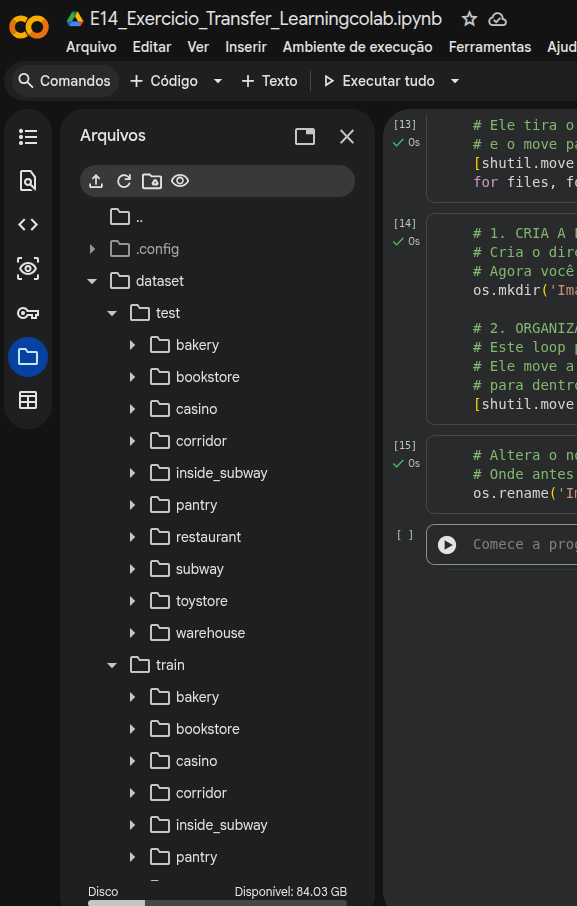

## 3. Preparando os datasets para uso no Pytorch

In [15]:
# 1. NÚCLEO DO PYTORCH:
import torch             # A biblioteca principal (como o "numpy" para tensores).
import torch.nn as nn    # Módulo de Redes Neurais (camadas lineares, convolucionais, etc.).
import torch.nn.functional as F # Funções matemáticas como ativações (ReLU, Softmax).
from torch import optim  # Algoritmos de otimização (Adam, SGD) que ajustam os pesos.

# 2. VISÃO COMPUTACIONAL:
from torchvision import datasets, models # Modelos prontos (VGG16, ResNet) e carregadores de dados.
import torchvision.transforms as transforms # Ferramentas para redimensionar e tratar as imagens.

# 3. UTILITÁRIOS:
from datetime import datetime # Usado para marcar o tempo de início e fim do treinamento.

# Reprodutibilidade
# 4. REPRODUTIBILIDADE (O PONTO CRUCIAL):
# O torch.manual_seed(124) fixa os números aleatórios do PyTorch.
# Isso garante que a inicialização dos pesos da rede seja sempre a mesma toda vez que rodarmos.
torch.manual_seed(124);

In [16]:
# 1. DEFINIÇÃO DOS CAMINHOS:
# Indica ao código onde estão as pastas que organizamos anteriormente.
data_dir_train = 'dataset/train'
data_dir_test = 'dataset/test'

# 2. PRÉ-PROCESSAMENTO (TRANSFORMS):
# O Compose agrupa várias etapas de tratamento:
# - Resize([224, 224]): Ajusta todas as fotos para o tamanho padrão que a VGG16 exige.
# - ToTensor(): Converte a imagem (que é um arquivo de imagem comum) em uma
#   matriz numérica (tensor) e escala os pixels de [0, 255] para [0, 1].
transform = transforms.Compose([transforms.Resize([224, 224]), transforms.ToTensor()])

# 3. CRIAÇÃO DOS DATASETS:
# O ImageFolder lê as pastas e automaticamente entende que cada subpasta é uma classe.
# Ele aplica as 'transforms' em cada imagem que for carregada.
train_dataset = datasets.ImageFolder(data_dir_train, transform = transform)
test_dataset = datasets.ImageFolder(data_dir_test, transform = transform)

# 4. CRIAÇÃO DOS LOADERS (CARREGADORES):
# O DataLoader é o que "serve" os dados para o modelo:
# - batch_size = 32: Ele não entrega 1 foto por vez, mas pacotes de 32 (mais rápido).
# - shuffle = True: Ele embaralha as fotos a cada época para a rede não "viciar" na ordem.
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 32, shuffle = True)

## 4. Definindo o modelo e parâmetros de treinamento

In [17]:
#o coração do projeto de Transfer Learning (Aprendizado por Transferência).

# 1. MODELS.VGG16:
# Carrega a arquitetura da VGG16, uma rede neural famosa com 16 camadas de profundidade,
# desenvolvida pelo grupo Visual Geometry Group de Oxford.

# 2. PRETRAINED = TRUE:
# Esta é a parte mágica. Ela baixa os "pesos" (o conhecimento) que a rede adquiriu
# ao ser treinada no dataset ImageNet (mais de 1.4 milhão de imagens e 1000 categorias).
# A rede já sabe reconhecer bordas, texturas, formas e objetos complexos.

model = models.vgg16(pretrained = True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 157MB/s]


In [18]:
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [19]:
from torchsummary import summary
summary(model, (3, 224, 224)) # Mostra o modelo e o tamanho que os dados ocupam

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
              ReLU-2         [-1, 64, 224, 224]               0
            Conv2d-3         [-1, 64, 224, 224]          36,928
              ReLU-4         [-1, 64, 224, 224]               0
         MaxPool2d-5         [-1, 64, 112, 112]               0
            Conv2d-6        [-1, 128, 112, 112]          73,856
              ReLU-7        [-1, 128, 112, 112]               0
            Conv2d-8        [-1, 128, 112, 112]         147,584
              ReLU-9        [-1, 128, 112, 112]               0
        MaxPool2d-10          [-1, 128, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]         295,168
             ReLU-12          [-1, 256, 56, 56]               0
           Conv2d-13          [-1, 256, 56, 56]         590,080
             ReLU-14          [-1, 256,

In [20]:
len(train_dataset), len(test_dataset)

(3514, 878)

In [21]:
len(train_dataset) + len(test_dataset)

4392

In [22]:
# 1. CAPTURA A ENTRADA:
# Ele olha para a última camada do classificador (índice 6) e pergunta:
# "Quantos neurônios chegam aqui?". Na VGG16, esse número é sempre 4096.
n_inputs = model.classifier[6].in_features
print(n_inputs)


# 2. CRIA A NOVA CAMADA:
# Cria uma nova camada linear que recebe os mesmos 4096 neurônios,
# mas entrega apenas o número de classes que nós temos (len(train_dataset.classes)).
classification_layer = nn.Linear(n_inputs, len(train_dataset.classes))

# 3. SUBSTITUIÇÃO:
# Remove a camada antiga de 1000 saídas e coloca a sua nova no lugar.
model.classifier[6] = classification_layer

# 4. VERIFICAÇÃO:
# Retorna o número de entrada (4096) e quantas categorias o atual modelo agora pode prever.
n_inputs, len(train_dataset.classes)

4096


(4096, 10)

In [23]:
n_inputs

4096

In [24]:
# 1. LOOP PELOS PARÂMETROS:
# O 'model.features' contém todas as camadas de convolução (o "olho" da rede).
# O loop percorre cada peso e viés dessas camadas.
for param in model.features.parameters():

    # 2. DESATIVANDO O GRADIENTE:
    # Ao definir 'requires_grad = False', nós dizemos ao PyTorch:
    # "Não calcule derivadas para estes pesos e não os atualize durante o treino".
    param.requires_grad = False

In [25]:
# 1. FUNÇÃO DE PERDA (CRITERION):
# O CrossEntropyLoss é o padrão para problemas de classificação (como o seu).
# Ele compara a previsão do modelo com a resposta real e gera um "puxão de orelha":
# - Se o modelo chutou "quarto" mas era "cozinha", o erro é alto.
# - Se o modelo acertou com confiança, o erro é baixo.
criterion = nn.CrossEntropyLoss()

# 2. OTIMIZADOR (OPTIMIZER):
# O Adam é um dos algoritmos de otimização mais eficientes atualmente.
# Ele é o responsável por atualizar os pesos da rede para diminuir o erro.
# 'model.parameters()' diz ao Adam: "Olhe para todos os pesos que NÃO estão congelados
# (a sua nova camada final) e ajuste-os para melhorar a acurácia".
optimizer = optim.Adam(model.parameters())

## 5. Treinamento e validação

In [26]:
# 1. ESCOLHA DO HARDWARE:
# Ele faz uma pergunta ao sistema: "Existe uma placa de vídeo pronta para uso (CUDA)?"
# - Se SIM: define o 'device' como 'cuda'.
# - Se NÃO: define o 'device' como 'cpu' (processamento padrão).
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 2. TRANSFERÊNCIA DO MODELO:
# Envia todos os pesos e a estrutura da sua VGG16 para o hardware escolhido.
# Se for 'cuda', a rede neural agora mora na memória da sua placa de vídeo.
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [27]:
device

device(type='cpu')

In [28]:
# treinamento
def training_loop(loader, epoch):

    #* Variáveis para acumular perda e precisão
    # Variáveis para acumular perda e precisão
    # Inicializa acumuladores para calcular a média no final da época
    running_loss = 0.
    running_accuracy = 0.

    # Itera sobre os pacotes (batches) de imagens do loader
    for i, data in enumerate(loader):
        # Itera sobre os pacotes (batches) de imagens do loader
        inputs, labels = data
        # Envia os dados para a GPU (ou CPU) definida anteriormente
        inputs, labels = inputs.to(device), labels.to(device)

        # Zera os gradientes acumulados para não somar o erro do loop anterior
        optimizer.zero_grad()

        # Forward: A rede tenta adivinhar o que tem na imagem
        # gerar a saída
        outputs = model(inputs)

        # Calcula o erro (perda) comparando o palpite com a realidade
        loss = criterion(outputs, labels)
        # Backward: O PyTorch calcula como ajustar cada peso para diminuir o erro
        loss.backward()
        # O otimizador (Adam) efetivamente altera os pesos da rede
        optimizer.step()
        # Acumula a perda para o relatório final
        running_loss += loss.item()

        # ** Como `output` não passou por ativação, vamos fazer isso agora usando a função `F.softmax`.
        # ** Em seguida, usamos `torch.argmax` para retornar o índice mais alto, que corresponde à predição.
        # Transforma a saída da rede em probabilidades e pega a maior delas
        predicted = torch.argmax(F.softmax(outputs, dim = 1), dim = 1)

        # ** Agora podemos ver quantas predições o modelo acertou
        # Compara as predições com os rótulos reais (True se acertou, False se errou)
        equals = predicted == labels

        # **A precisão será igual à média da variável anterior (número de `True` dividido pelo total)
        # Calcula a média de acertos neste pacote (batch)
        accuracy = torch.mean(equals.float())
        running_accuracy += accuracy

        # Imprimindo os dados referentes a este loop
        # Print de acompanhamento em tempo real
        print('Época {} | loop {}/{}: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, i + 1, len(loader), loss.item(), accuracy))

    # Imprimindo os dados referentes a esta época

    print('>>>>> ÉPOCA {} FINALIZADA: perda {:.5f} - precisão {:.5f}'.format(epoch + 1, running_loss/len(loader), running_accuracy/len(loader)))
    # adicionar
    # Imprimindo os dados referentes a esta época
    epoch_loss = running_loss/len(loader)
    epoch_acc = running_accuracy/len(loader)

    return epoch_loss, epoch_acc # Retornamos os valores para poder plotar o gráfico depois



Treinando...
Época 1 | loop 1/110: perda 2.31849 - precisão 0.15625
Época 1 | loop 2/110: perda 1.85576 - precisão 0.40625
Época 1 | loop 3/110: perda 2.80882 - precisão 0.18750
Época 1 | loop 4/110: perda 3.33584 - precisão 0.18750
Época 1 | loop 5/110: perda 2.17702 - precisão 0.34375
Época 1 | loop 6/110: perda 2.68879 - precisão 0.31250
Época 1 | loop 7/110: perda 1.76219 - precisão 0.43750
Época 1 | loop 8/110: perda 1.66032 - precisão 0.40625
Época 1 | loop 9/110: perda 1.90966 - precisão 0.40625
Época 1 | loop 10/110: perda 1.49211 - precisão 0.56250
Época 1 | loop 11/110: perda 1.34182 - precisão 0.53125
Época 1 | loop 12/110: perda 1.83135 - precisão 0.50000
Época 1 | loop 13/110: perda 1.50697 - precisão 0.50000
Época 1 | loop 14/110: perda 1.52990 - precisão 0.65625
Época 1 | loop 15/110: perda 1.74052 - precisão 0.50000
Época 1 | loop 16/110: perda 1.36301 - precisão 0.56250
Época 1 | loop 17/110: perda 1.73251 - precisão 0.53125
Época 1 | loop 18/110: perda 1.82385 - preci

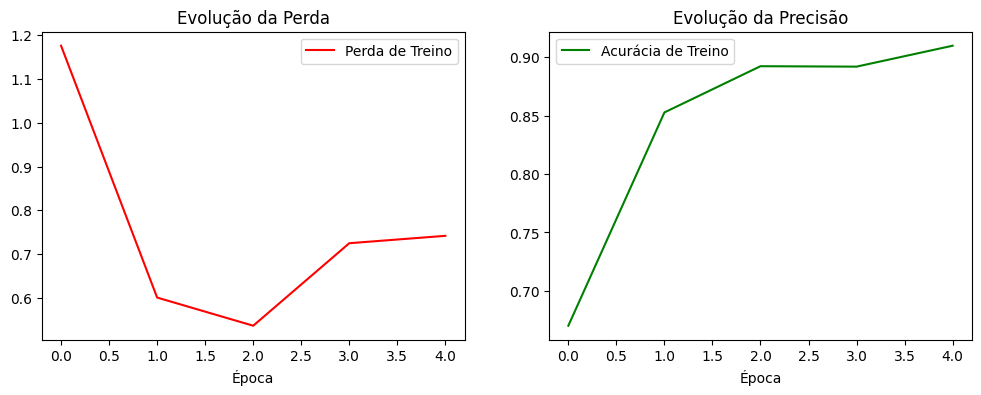

In [29]:
# 1. Criar listas para armazenar o histórico
historico_perda = []
historico_acuracia = []

# 2. O LOOP DE ÉPOCAS:
start = datetime.now() # horário que inicio o programa treinamento
# Uma "época" significa que o modelo viu TODO o seu dataset uma vez.
# Aqui, ele vai repetir o processo 5 vezes para tentar decorar os padrões.
for epoch in range(5): # pode rodar de 30 e 20, mas o transfer já treinou exaustivamente antes, por isso 5
    print('Treinando...')
    # adaptado
    # 3. MODO DE TREINO:
    # Executa a sua função 'training_loop' usando as imagens de treino.
    loss, acc =  training_loop(train_loader, epoch)
    historico_perda.append(loss)
    historico_acuracia.append(acc.cpu().numpy()) # Move para CPU para o gráfico
    # volta, antes era somente o training_loop(train_loader, epoch)
    # 4. MODO DE AVALIAÇÃO (EVAL):
    # Avisa ao PyTorch: "Vou testar agora!". Isso desativa coisas como o Dropout,
    # garantindo que o modelo use todo o seu potencial para prever sem "ruído".

    #o PyTorch, isso é o Dropout: nós "desligamos" aleatoriamente alguns neurônios.
    #Por que fazemos isso? Para forçar o atleta a ficar mais forte e não depender de um único músculo (ou neurônio).
    #Isso evita que o modelo apenas "decore" as fotos (o famoso overfitting).
    #Na hora da competição oficial (a validação/teste), você tira os pesos do atleta.
    # queremos que ele use 100% da sua força e técnica original para conseguir o salto mais alto possível.
    #O que o model.eval() faz? Ele desativa esses "obstáculos"
    #(como o Dropout e a Batch Normalization). Ele diz ao PyTorch: "Agora é sério, use todos os neurônios
    #e todo o conhecimento que você adquiriu para me dar a resposta mais precisa".
    model.eval()
    print('Validando...')
    # 5. TESTE/VALIDAÇÃO:
    # Roda a mesma função, mas agora com o 'test_loader' (as fotos que ele nunca viu).
    training_loop(test_loader, epoch)
    # 6. VOLTA PARA MODO DE TREINO:
    # Prepara a rede para a próxima época, reativando camadas específicas de treino.
    model.train()
    #model.train()
    #A VGG16 usa uma técnica chamada Dropout. Imagine que, para aprender a reconhecer uma "Cozinha",
    # o modelo às vezes "tampa um olho" ou "ignora a geladeira".
    # Por que? Para que ele não dependa de um único objeto para dar a resposta.
    #Ele é forçado a olhar para o todo (o fogão, o azulejo, a pia).
    #O model.train() ativa esse comportamento de "tampar os olhos" (ignorar neurônios aleatórios).
    # Quando você roda model.train(), o PyTorch "liga" uma chave que faz com que,
    #a cada imagem que passa pela rede, alguns neurônios sejam desativados aleatoriamente (viram zero).
    # O Objetivo: Forçar a rede a não ser "preguiçosa".
    #Exemplo Prático: Se a rede está aprendendo a reconhecer uma Cozinha, e ela sempre foca apenas na Geladeira,
    #o Dropout vai lá e "esconde" a geladeira em algumas rodadas.
    #A Consequência: A rede é obrigada a aprender que uma cozinha também tem fogões, azulejos e armários.
    #Isso evita que ela decore apenas um detalhe e ignore o resto (o que chamamos de Overfitting).

    end = datetime.now() # horário que terminou o treinamento

print('Treinamento/validação demorou {}'.format(end - start))


# 3. Criar o gráfico
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Gráfico de Perda (Loss) - Deve diminuir
plt.subplot(1, 2, 1)
plt.plot(historico_perda, label='Perda de Treino', color='red')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.legend()

# Gráfico de Precisão (Accuracy) - Deve aumentar
plt.subplot(1, 2, 2)
plt.plot(historico_acuracia, label='Acurácia de Treino', color='green')
plt.title('Evolução da Precisão')
plt.xlabel('Época')
plt.legend()

plt.show()


gráfico

Perda (Loss): A curva vermelha deve descer. Se ela estiver subindo ou oscilando muito, a "Taxa de Aprendizado" (Learning Rate) pode estar alta demais.

Precisão (Accuracy): A curva verde deve subir. Como está sendo usado a VGG16 (uma rede potente), é comum ela subir rápido logo nas primeiras épocas.

## 6. Verificação

In [30]:
# 1. PEGA UMA AMOSTRA:
# O iter() transforma o loader em um iterador e o next() "fisga" o primeiro pacote (batch).
# Como seu batch_size é 32, você agora tem 32 imagens e suas 32 etiquetas reais.
images, labels = next(iter(test_loader))

# 2. MODO DE PROVA:
# Desativa o Dropout (tira os "pesos do tornozelo") para ter a máxima precisão.
model.eval()

# 3. INFERÊNCIA (O PALPITE):
# - Envia as imagens para a GPU (.to(device)).
# - Passa as fotos pela VGG16 (model(images)).
# - Traz o resultado de volta para o processador (.cpu()) para facilitar a análise.
predicted = model(images.to(device)).cpu()

# 4. TRADUÇÃO DO RESULTADO:
# O modelo cospe números brutos (logits).
# - F.softmax: Transforma esses números em probabilidades (ex: 90% chance de ser 'cozinha').
# - torch.argmax: Pega o índice do maior valor (o palpite com mais certeza).
predicted = torch.argmax(F.softmax(predicted, dim = 1), dim = 1)

In [ ]:
# 1. O QUE TEMOS ORIGINALMENTE (test_dataset.class_to_idx):
# O PyTorch guarda as classes assim: {'bedroom': 0, 'kitchen': 1, 'livingroom': 2}
# Isso é bom para o modelo, mas ruim para a gente ler os resultados.

# 2. A INVERSÃO (Dictionary Comprehension):
# O código percorre o dicionário original e inverte a posição:
# Onde era 'nome: numero', vira 'numero: nome'.
idx_to_class = {k: v for v, k in test_dataset.class_to_idx.items()}
idx_to_class
# RESULTADO FINAL:
# {0: 'bedroom', 1: 'kitchen', 2: 'livingroom'}

In [32]:
# 1. .detach():
# Corta a conexão do tensor com o "gráfico de computação".
# Isso diz ao PyTorch: "Não precisa mais rastrear gradientes ou cálculos para esse número".

# 2. .numpy():
# Converte o objeto do tipo 'Torch Tensor' para um 'NumPy Array'.

labels, predicted = labels.detach().numpy(), predicted.detach().numpy()

In [33]:
# 1. TRADUÇÃO DAS ETIQUETAS REAIS (Labels):
# Percorre a lista de números que representam a verdade absoluta (labels)
# e troca cada número pelo nome da categoria correspondente.
labels = [idx_to_class[label] for label in labels]
print(labels)
# 2. TRADUÇÃO DOS PALPITES (Predicted):
# Faz exatamente o mesmo com a lista de resultados que a VGG16 previu.
predicted = [idx_to_class[label] for label in predicted]
print(predicted)

['corridor', 'subway', 'corridor', 'bookstore', 'toystore', 'bookstore', 'pantry', 'warehouse', 'pantry', 'inside_subway', 'bakery', 'warehouse', 'casino', 'restaurant', 'pantry', 'bookstore', 'subway', 'corridor', 'warehouse', 'casino', 'bookstore', 'toystore', 'bakery', 'pantry', 'subway', 'toystore', 'subway', 'corridor', 'restaurant', 'inside_subway', 'casino', 'bakery']
['corridor', 'subway', 'corridor', 'bookstore', 'toystore', 'bookstore', 'pantry', 'warehouse', 'pantry', 'inside_subway', 'bakery', 'warehouse', 'casino', 'restaurant', 'pantry', 'bookstore', 'subway', 'corridor', 'warehouse', 'casino', 'bookstore', 'toystore', 'bakery', 'pantry', 'subway', 'toystore', 'subway', 'corridor', 'restaurant', 'inside_subway', 'casino', 'bakery']


In [34]:
images.shape

torch.Size([32, 3, 224, 224])

In [35]:

# permuta as imagens

# 1. PERMUTE(0, 2, 3, 1):
# O PyTorch usa o padrão (Canais, Altura, Largura).
# O Matplotlib/Numpy usa o padrão (Altura, Largura, Canais).
# Este comando troca a ordem: o canal (índice 1) vai para o final da fila (índice 3).
#torch.Size([32, 3, 224, 224])# 0,1,2,3

# 2. NUMPY():
# Converte o tensor do PyTorch em uma matriz do Numpy.
# Isso é necessário porque bibliotecas de visualização não entendem tensores do PyTorch diretamente.

images = images.permute(0, 2, 3, 1).numpy()

In [36]:
# 1. .permute(0, 2, 3, 1):
# O PyTorch organiza imagens como (Batch, Canais, Altura, Largura) -> (B, C, H, W).
# O Matplotlib exige o formato (Batch, Altura, Largura, Canais) -> (B, H, W, C).
# O permute "reorganiza as gavetas":
# 0 continua sendo o Batch, mas o 1 (Canais) vai para o final da fila.



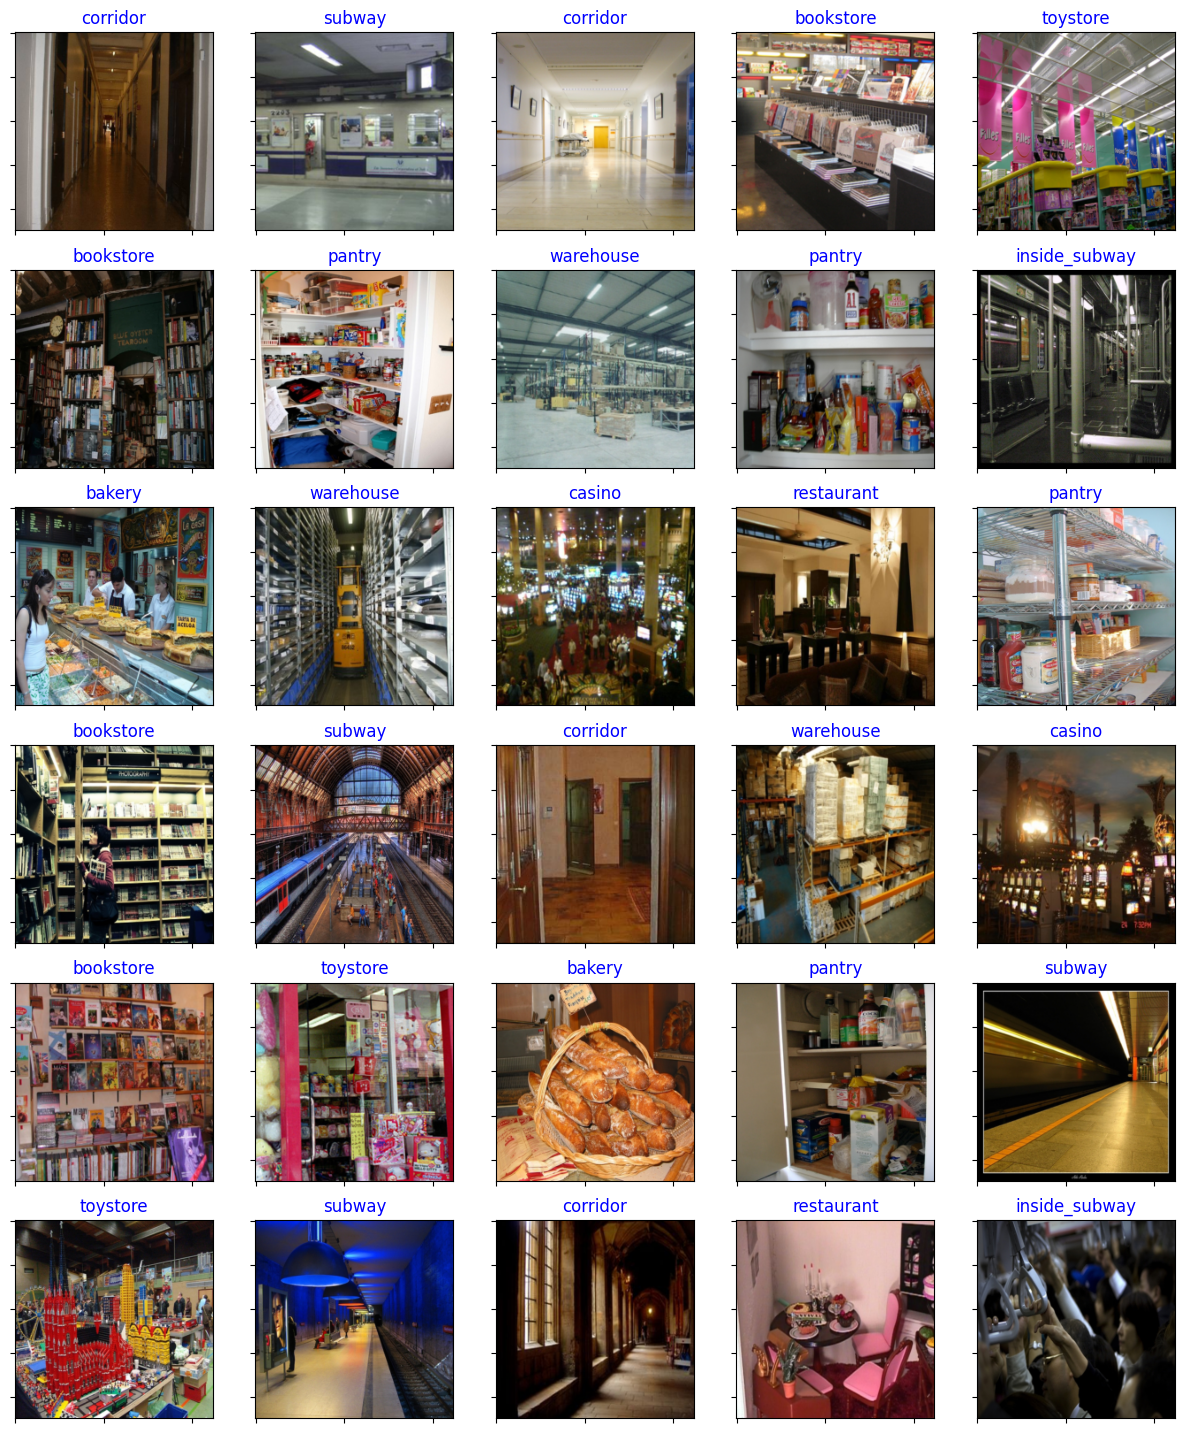

In [37]:
import matplotlib.pyplot as plt
# 1. CRIAÇÃO DA GRADE (CANVAS):
# Cria uma figura com 30 subgráficos organizados em 6 linhas e 5 colunas.
# 'figsize' define o tamanho da imagem final para que não fique tudo apertado.
fig, ax = plt.subplots(6, 5, figsize = (15, 18))

i = 0
# 2. LOOP PELAS LINHAS E COLUNAS:
for row in range(6):
    ax_row = ax[row] # Seleciona a linha atual
    for column in range(5):
        ax_column = ax_row[column] # Seleciona o "quadradinho" (eixo) atual

        # 3. MOSTRAR A IMAGEM:
        # Coloca a imagem 'i' no quadradinho correspondente.
        ax_column.imshow(images[i])

        # 4. LIMPEZA VISUAL:
        # Remove os números dos eixos X e Y (coordenadas de pixels) para o gráfico ficar limpo.
        ax_column.set_xticklabels([])
        ax_column.set_yticklabels([])

        # 5. LÓGICA DE COR (O PULO DO GATO):
        # Se o modelo acertou (label == predicted), a cor será azul.
        # Se o modelo errou, a cor será vermelha.
        col = 'blue' if labels[i] == predicted[i] else 'red'

        # 6. TÍTULO:
        # Escreve o nome da classe que o modelo previu no topo da imagem com a cor definida.
        ax_column.set_title(predicted[i], color = col)

        i += 1 # Passa para a próxima imagem